In [60]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


import time
import matplotlib.pyplot as plt

In [61]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(0.5), # data augmentation
    transforms.RandomRotation(10),      
    transforms.ToTensor(),
])

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Matches your 96x96 grayscale requirement
    transforms.Resize((96, 96)),
    transforms.ToTensor(), # Normalizes pixel values to [0, 1]
])

train_dataset = datasets.ImageFolder(root='data/training/', transform=train_transform)
test_dataset = datasets.ImageFolder(root='data/testing/', transform=transform)

print(f"Total training images: {len(train_dataset)}")
print(f"Total testing images: {len(test_dataset)}")
print(f"Classes found: {test_dataset.classes}")

# Splitting dataset into training and validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, shuffle=False)

Total training images: 187
Total testing images: 43
Classes found: ['idle', 'next_track', 'play_pause', 'previous_track']


In [62]:
class CNN(torch.nn.Module):
    def __init__(self, num_outputs):
        super(CNN, self).__init__()
        self.convl = torch.nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1)
        self.rll = torch.nn.ReLU()
        self.maxl = torch.nn.MaxPool2d(kernel_size=3, stride=2)
        
        self.conv2 = torch.nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2)
        self.rl2 = torch.nn.ReLU()
        self.max2 = torch.nn.MaxPool2d(kernel_size=3, stride=2)
        
        self.conv3 = torch.nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
        self.rl3 = torch.nn.ReLU()
        
        self.conv4 = torch.nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1)
        self.rl4 = torch.nn.ReLU()
        
        self.conv5 = torch.nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1)
        self.rl5 = torch.nn.ReLU()
        self.max3 = torch.nn.MaxPool2d(kernel_size=3, stride=2)
        
        self.flatten = torch.nn.Flatten()
        self.linearl = torch.nn.Linear(256, 128)
        self.rl6 = torch.nn.ReLU()
        self.dropoutl = torch.nn.Dropout(0.5)
        
        self.linear2 = torch.nn.Linear(128, 64)
        self.rl7 = torch.nn.ReLU()
        self.dropout2 = torch.nn.Dropout(0.5)
        
        self.linear3 = torch.nn.Linear(64, num_outputs)

    def forward(self, x):
        out = self.maxl(self.rll(self.convl(x)))
        out = self.max2(self.rl2(self.conv2(out)))
        out = self.rl3(self.conv3(out))
        out = self.rl4(self.conv4(out))
        out = self.rl5(self.conv5(out))
        out = self.max3(out)
        out = self.flatten(out)
        out = self.dropoutl(self.rl6(self.linearl(out)))
        out = self.dropout2(self.rl7(self.linear2(out)))
        out = self.linear3(out)
        return out

def init_weights(m):
    if type(m) == torch.nn.Linear or type(m) == torch.nn.Conv2d:
        torch.nn.init.xavier_uniform_(m.weight)

num_classes = 4
model = CNN(num_outputs=num_classes).to(device)
model.apply(init_weights)

CNN(
  (convl): Conv2d(1, 96, kernel_size=(11, 11), stride=(4, 4), padding=(1, 1))
  (rll): ReLU()
  (maxl): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (rl2): ReLU()
  (max2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rl3): ReLU()
  (conv4): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rl4): ReLU()
  (conv5): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rl5): ReLU()
  (max3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linearl): Linear(in_features=256, out_features=128, bias=True)
  (rl6): ReLU()
  (dropoutl): Dropout(p=0.5, inplace=False)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (rl7): ReLU()
  (dropout2): 

In [63]:
def correct(logits, y):
    y_hat = logits.argmax(axis=1)
    return (y_hat == y).float().sum()
    
def evaluate_metric(model, data_iter, metric):
    c = 0.
    n = 0.
    model.eval()
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            c += metric(logits, y)
            n += len(y)
    return float(c / n)

Epoch [1/30]
Train Loss: 0.8552 | Train Acc: 65.77%
Val Acc: 50.00% | Duration: 2.885s
------------------------------
Epoch [2/30]
Train Loss: 0.8856 | Train Acc: 65.77%
Val Acc: 47.37% | Duration: 3.219s
------------------------------
Epoch [3/30]
Train Loss: 0.7968 | Train Acc: 69.80%
Val Acc: 47.37% | Duration: 3.292s
------------------------------
Epoch [4/30]
Train Loss: 0.8812 | Train Acc: 68.46%
Val Acc: 52.63% | Duration: 3.893s
------------------------------
Epoch [5/30]
Train Loss: 0.7763 | Train Acc: 71.14%
Val Acc: 50.00% | Duration: 2.880s
------------------------------
Epoch [6/30]
Train Loss: 0.7108 | Train Acc: 71.81%
Val Acc: 50.00% | Duration: 2.745s
------------------------------
Epoch [7/30]
Train Loss: 0.7943 | Train Acc: 67.79%
Val Acc: 50.00% | Duration: 2.654s
------------------------------
Epoch [8/30]
Train Loss: 0.7228 | Train Acc: 69.80%
Val Acc: 52.63% | Duration: 2.861s
------------------------------
Epoch [9/30]
Train Loss: 0.6741 | Train Acc: 74.50%
Val 

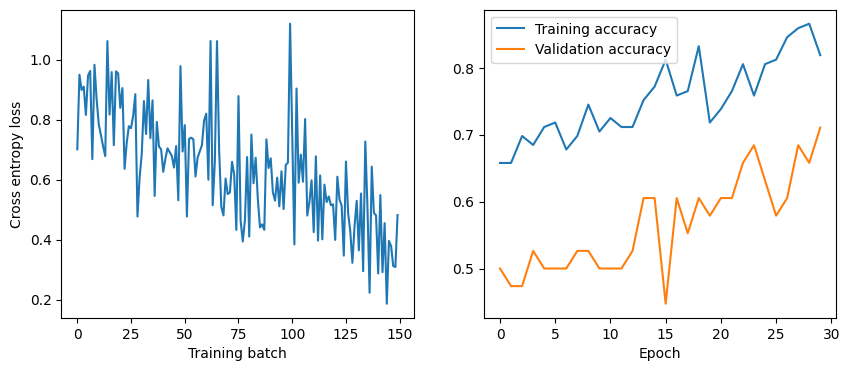

In [66]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
num_epochs = 30

losses = []
train_accs = []
test_accs = []

for epoch in range(num_epochs):
    model.train()
    start_time = time.perf_counter()
    train_loss = 0.0
    train_correct_count = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss_val = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
        
        losses.append(loss_val.item())
        train_loss += loss_val.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct_count += (predicted == labels).sum().item()

    train_acc = 100 * train_correct_count / train_total
    val_acc = evaluate_metric(model, val_loader, correct) * 100
    
    train_accs.append(train_acc / 100)
    test_accs.append(val_acc / 100)
    
    end_time = time.perf_counter()
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}% | Duration: {end_time - start_time:.3f}s")
    print("-" * 30)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Training batch')
plt.ylabel('Cross entropy loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training accuracy')
plt.plot(test_accs, label='Validation accuracy')
plt.xlabel('Epoch')
plt.legend(loc='best')
plt.show()

Epoch [1/10]
Train Loss: 0.6137 | Train Acc: 76.51%
Val Acc: 52.63% | Duration: 3.392s
--> Best model saved (Val Acc: 52.63%)
------------------------------
Epoch [2/10]
Train Loss: 0.5844 | Train Acc: 81.88%
Val Acc: 76.32% | Duration: 3.169s
--> Best model saved (Val Acc: 76.32%)
------------------------------
Epoch [3/10]
Train Loss: 0.4375 | Train Acc: 86.58%
Val Acc: 57.89% | Duration: 3.509s
No improvement for 1 epoch(s).
------------------------------
Epoch [4/10]
Train Loss: 0.4519 | Train Acc: 83.89%
Val Acc: 65.79% | Duration: 2.899s
No improvement for 2 epoch(s).
------------------------------
Epoch [5/10]
Train Loss: 0.4141 | Train Acc: 87.25%
Val Acc: 71.05% | Duration: 3.228s
No improvement for 3 epoch(s).
------------------------------
Epoch [6/10]
Train Loss: 0.2856 | Train Acc: 90.60%
Val Acc: 65.79% | Duration: 3.616s
No improvement for 4 epoch(s).
------------------------------
Epoch [7/10]
Train Loss: 0.3339 | Train Acc: 84.56%
Val Acc: 73.68% | Duration: 3.221s
No 

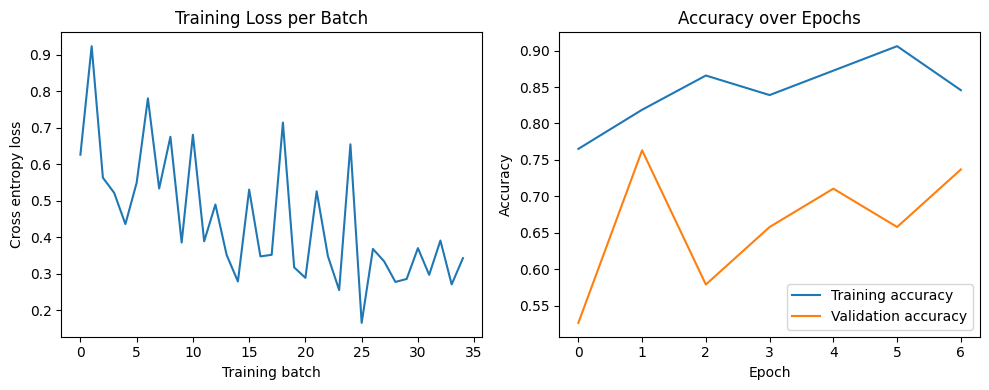

In [67]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
num_epochs = 10

losses = []
train_accs = []
test_accs = []


best_val_acc = 0.0
patience = 5      
counter = 0    
best_model_path = 'best_model.pth'


for epoch in range(num_epochs):
    model.train()
    start_time = time.perf_counter()
    train_loss = 0.0
    train_correct_count = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        
        outputs = model(images)
        loss_val = criterion(outputs, labels)
        
        
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
        
        
        losses.append(loss_val.item())
        train_loss += loss_val.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct_count += (predicted == labels).sum().item()

    
    model.eval() 
    with torch.no_grad():
        val_acc_raw = evaluate_metric(model, val_loader, correct)
        val_acc = val_acc_raw * 100
    
    train_acc = 100 * train_correct_count / train_total
    train_accs.append(train_acc / 100)
    test_accs.append(val_acc_raw)
    
    end_time = time.perf_counter()
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}% | Duration: {end_time - start_time:.3f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"--> Best model saved (Val Acc: {val_acc:.2f}%)")
    else:
        counter += 1
        print(f"No improvement for {counter} epoch(s).")
    
    if counter >= patience:
        print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}")
        break
    print("-" * 30)

model.load_state_dict(torch.load(best_model_path))
print(f"\nLoaded best model with Validation Accuracy: {best_val_acc:.2f}%")

model.eval()
final_test_acc = evaluate_metric(model, val_loader, correct)
print(f"Final Test Accuracy (Best Model): {final_test_acc * 100:.2f}%")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Training Loss per Batch')
plt.xlabel('Training batch')
plt.ylabel('Cross entropy loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training accuracy')
plt.plot(test_accs, label='Validation accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

In [68]:
model.eval()

with torch.no_grad():
    test_acc = evaluate_metric(model, test_loader, correct)

print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

Final Test Accuracy: 79.07%
